# Reflection, Family Focus, and Exploration Analysis

This notebook analyzes one reflexion-enabled MADE experiment run to answer:
1. Do self-reflections appear to change subsequent behavior?
2. How does focus shift across families and n-ary levels (binary/ternary/etc.)?
3. Under what circumstances are new families introduced (exploration vs. exploitation)?


In [95]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_colwidth', 220)
plt.style.use('default')

RUN_DIR = Path(
    '/Users/weiyong/Code/intern_codes/MADE/results/baselines/custom/'
    'qwen3dot5-122b-reflx-tracking/systems_ternary_n10_maxatoms20_intermetallic_smact/'
    '20260317-220021/llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact_2systems_50queries_100stabilitymeV'
)
assert RUN_DIR.exists(), f'Run directory not found: {RUN_DIR}'
RUN_DIR


PosixPath('/Users/weiyong/Code/intern_codes/MADE/results/baselines/custom/qwen3dot5-122b-reflx-tracking/systems_ternary_n10_maxatoms20_intermetallic_smact/20260317-220021/llm_react_orchestrator_systems_ternary_n10_maxatoms20_intermetallic_smact_2systems_50queries_100stabilitymeV')

In [96]:
FORMULA_PATTERN = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def parse_formula(formula: str) -> dict[str, float]:
    if not isinstance(formula, str) or not formula.strip():
        return {}
    clean = formula.replace(' ', '')
    parsed: dict[str, float] = {}
    for elem, raw_count in FORMULA_PATTERN.findall(clean):
        count = float(raw_count) if raw_count else 1.0
        parsed[elem] = parsed.get(elem, 0.0) + count
    return parsed

def canonical_family(formula: str) -> str:
    comp = parse_formula(formula)
    return '-'.join(sorted(comp)) if comp else 'UNKNOWN'

def arity(formula: str) -> int:
    return len(parse_formula(formula))

def arity_label(n: int) -> str:
    mapping = {1: 'unary', 2: 'binary', 3: 'ternary', 4: 'quaternary'}
    return mapping.get(int(n), f'{int(n)}-ary')

def extract_episode_id(path: Path) -> int:
    m = re.search(r'episode_(\d+)', path.stem)
    return int(m.group(1)) if m else -1


In [97]:
def load_trajectory_steps(run_dir: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for system_dir in sorted((run_dir / 'systems').iterdir()):
        if not system_dir.is_dir():
            continue
        for traj_file in sorted((system_dir / 'trajectories').glob('episode_*.json')):
            payload = json.loads(traj_file.read_text())
            episode_id = extract_episode_id(traj_file)
            for q_idx, step in enumerate(payload.get('trajectory', [])):
                rf = step.get('reduced_formula', '')
                row = {
                    'system_id': system_dir.name,
                    'episode_id': episode_id,
                    'query_idx': q_idx,
                    'reduced_formula': rf,
                    'family': canonical_family(rf),
                    'arity': arity(rf),
                    'arity_label': arity_label(arity(rf)),
                    'e_above_hull': step.get('e_above_hull'),
                    'is_stable': bool(step.get('is_stable', False)),
                    'is_newly_discovered': bool(step.get('is_newly_discovered', False)),
                    'formation_energy_per_atom': step.get('formation_energy_per_atom'),
                }
                for k, v in (step.get('agent_behavior_metrics') or {}).items():
                    row[f'bm_{k}'] = v
                rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['system_id', 'episode_id', 'query_idx']).reset_index(drop=True)
    return df

def load_episode_summaries(run_dir: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for system_dir in sorted((run_dir / 'systems').iterdir()):
        if not system_dir.is_dir():
            continue
        p = system_dir / 'summary' / 'episodes.json'
        if not p.exists():
            continue
        for item in json.loads(p.read_text()):
            rows.append({'system_id': system_dir.name, **item})
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['system_id', 'episode_id']).reset_index(drop=True)
    return df

def load_reflections(run_dir: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for system_dir in sorted((run_dir / 'llm_traces').iterdir()):
        if not system_dir.is_dir():
            continue
        for trace_file in sorted(system_dir.glob('episode_*.jsonl')):
            episode_id = extract_episode_id(trace_file)
            lines = [json.loads(x) for x in trace_file.read_text().splitlines() if x.strip()]
            first_orch = next((x for x in lines if x.get('component') == 'orchestrator'), {})
            first_thought = (first_orch.get('output', {})
                             .get('trajectory', {})
                             .get('thought_0'))
            refl = next((x for x in reversed(lines) if x.get('component') == 'self_reflection'), {})
            reflection = (refl.get('output', {}) or {}).get('reflection')
            rows.append({
                'system_id': system_dir.name,
                'episode_id': episode_id,
                'first_thought': first_thought,
                'reflection': reflection,
                'has_reflection': bool(reflection),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['system_id', 'episode_id']).reset_index(drop=True)
    return df


In [98]:
df_steps = load_trajectory_steps(RUN_DIR)
df_episodes = load_episode_summaries(RUN_DIR)
df_reflections = load_reflections(RUN_DIR)

print(f'Loaded query steps: {len(df_steps):,}')
print(f'Loaded episode summaries: {len(df_episodes):,}')
print(f'Loaded reflection rows: {len(df_reflections):,}')
print('Systems:', sorted(df_steps.system_id.unique().tolist()))
display(df_steps.groupby('system_id')['episode_id'].nunique().rename('num_episodes').to_frame())


Loaded query steps: 500
Loaded episode summaries: 10
Loaded reflection rows: 10
Systems: ['Au-K-Tb', 'Mg-Sn-Sr']


,num_episodes
system_id,
Au-K-Tb,5
Mg-Sn-Sr,5


## 1) Self-Reflections Extracted Per Episode

In [99]:
def preview(text: str | None, n: int = 220) -> str:
    if not isinstance(text, str):
        return ''
    t = ' '.join(text.split())
    return t if len(t) <= n else t[:n] + ' ...'

refl_view = df_reflections.copy()
refl_view['reflection_preview'] = refl_view['reflection'].map(preview)
refl_view['first_thought_preview'] = refl_view['first_thought'].map(lambda x: preview(x, 160))
display(refl_view[['system_id', 'episode_id', 'has_reflection', 'reflection_preview', 'first_thought_preview']])


,system_id,episode_id,has_reflection,reflection_preview,first_thought_preview
0,Au-K-Tb,0,True,"* **Prioritize Au-Tb Binary Subsystem:** Focus search efforts on the Au-Tb edge first, as K-containing ternaries showed consistently high instability (>0.25 eV/atom). * **Restrict Potassium Content:** High K stoichio...",The buffer is empty and this is the start of the discovery process. I need to populate the buffer with candidate structures before I can select any for oracle e ...
1,Au-K-Tb,1,True,* **Eliminate Potassium:** Completely exclude K-containing compositions from the search space; all K-ternaries evaluated were highly unstable (>0.15 eV/atom). * **Enforce Stoichiometry Deduplication:** Implement a st...,"The buffer is empty and I have valuable prior reflections from Episode 1. Key insights: (1) Au-Tb binaries are more promising than K-containing ternaries, (2) K ..."
2,Au-K-Tb,2,True,on ## ]] {reflection},"The buffer is empty with no candidates yet. Based on prior reflections from Episodes 1 and 2, I should: 1. Focus on Au-Tb binary compositions (K-containing comp ..."
3,Au-K-Tb,3,True,"* **Enforce Stoichiometry Uniqueness:** Implement a hard limit of one query per unique stoichiometry (e.g., Au5Tb1). If the first structure for a ratio exceeds 0.05 eV/atom, discard the ratio immediately rather than ...","The buffer is empty, so I need to generate initial candidate structures. Based on prior reflections, focus on Au-Tb binaries (avoiding K) with known stable stoi ..."
4,Au-K-Tb,4,True,"* **Fix Stability Counting Threshold**: Ensure structures with e_above_hull < 0.05 eV/atom are counted as stable; the episode found 3 such structures (#3, #11, #15) but outcome reported 0. Verify oracle threshold ali...","The buffer is empty and no evaluations have been done yet. Based on prior reflections from Episodes 1 and 3, I need to: 1. Exclude K-containing compositions (al ..."
5,Mg-Sn-Sr,0,True,* Enforce a strict e_above_hull < 0.05 eV/atom threshold during candidate selection to align with the final stability criteria and reduce false positives. * Implement composition and structure deduplication checks to...,The buffer is empty and this is the start of the discovery process for the Mg-Sn-Sr ternary system. I need to begin generating candidate structures. Looking at ...
6,Mg-Sn-Sr,1,True,"* **Enforce Strict Composition Deduplication:** Implement a hard limit on queries per unique stoichiometry (e.g., max 2) to prevent the agent from fixating on `Mg1 Sn2 Sr1` and ensure broader coverage of the Mg-Sn-Sr...","The buffer is empty and we have no prior evaluations. Based on the prior reflections from Episode 1, I should focus on Mg-containing ternary compositions since ..."
7,Mg-Sn-Sr,2,True,* **Implement Hard Deduplication Constraints:** Enforce a system-level limit of 2 queries per unique stoichiometry to prevent fixation on ratios like `Sr2MgSn4` and force broader chemical space coverage. * **Enforce ...,"The buffer is empty and I need to start generating candidate structures for the Mg-Sn-Sr ternary system. Based on prior reflections, I should: 1. Focus on Mg-co ..."
8,Mg-Sn-Sr,3,True,"* **Enforce Hard Deduplication:** Implement a system-level block preventing more than one query per unique stoichiometry to eliminate redundancy (e.g., stop querying `Sr2MgSn3` after the first attempt). * **Mandatory...","The buffer is empty and we have no evaluations yet. Based on prior reflections from Episodes 1-3, I need to: 1. Generate diverse compositions (Mg-rich and Sr-ri ..."
9,Mg-Sn-Sr,4,True,* **Enforce Strict Energy Cutoff:** Discard any candidate with predicted `e_above_hull` > 0.03 eV/atom before oracle submission; 60% of this episode's budget was wasted on structures > 0.1 eV/atom. * **Validate Novel...,"The buffer is empty and we have no evaluation history yet. Based on prior reflections from Episodes 1-3, I need to: 1. Diversify composition sampling - avoid cl ..."


In [100]:
for _, row in df_reflections.iterrows():
    display(Markdown(f"### {row.system_id} - Episode {int(row.episode_id)} Reflection"))
    display(Markdown(row.reflection if isinstance(row.reflection, str) else '(missing reflection)'))
    display(Markdown('---'))


### Au-K-Tb - Episode 0 Reflection

*   **Prioritize Au-Tb Binary Subsystem:** Focus search efforts on the Au-Tb edge first, as K-containing ternaries showed consistently high instability (>0.25 eV/atom).
*   **Restrict Potassium Content:** High K stoichiometry appears thermodynamically unfavorable; limit K concentration to <20 at% to reduce risk of phase separation.
*   **Cap Redundant Stoichiometry Queries:** Limit sampling of any single ternary formula to 2 attempts; if energies remain >0.2 eV/atom, switch to new compositions immediately.
*   **Prefer Smaller Unit Cells:** Bias structure generation toward cells with <6 sites, as the lowest energy structure (Au2Tb1) was a 3-site cell.

---

### Au-K-Tb - Episode 1 Reflection

*   **Eliminate Potassium:** Completely exclude K-containing compositions from the search space; all K-ternaries evaluated were highly unstable (>0.15 eV/atom).
*   **Enforce Stoichiometry Deduplication:** Implement a strict check to prevent re-querying identical stoichiometries (e.g., Au3Tb2 was queried twice with no improvement).
*   **Target Specific Ratios:** Narrow the focus to Au-Tb stoichiometries near 3:2 and 3:1 where the lowest energies (0.029-0.041 eV/atom) were observed, rather than broad exploration.
*   **Bias Towards Small Cells:** Prioritize structure generation for unit cells with 4-6 sites, as these correlated with the most stable candidates found.
*   **Prioritize Known Phases:** Shift strategy from novelty to recall; explicitly query known stable stoichiometries from literature to recover the 0.000 recall score.

...

*   **Enforce Hard Deduplication:** Implement a system-level block preventing more than one query per unique stoichiometry to eliminate redundancy (e.g., stop querying `Sr2MgSn3` after the first attempt).
*   **Mandatory Pre-Query Novelty Check:** Cross-reference all generated candidates against the known stable database *before* oracle submission to avoid wasting queries on rediscovered phases like `Mg2Sn2Sr1`.
*   **Strict Energy Pre-Filter:** Discard any candidate with predicted `e_above_hull` > 0.05 eV/atom immediately to prevent budget waste on clearly unstable structures (>50% of this episode).
*   **Diversify Composition Sampling:** Avoid clustering around 1:2:1 ratios; use temperature-scaled sampling to actively explore under-sampled Mg-rich and Sr-rich regions.

---

### Mg-Sn-Sr - Episode 4 Reflection

*   **Enforce Strict Energy Cutoff:** Discard any candidate with predicted `e_above_hull` > 0.03 eV/atom before oracle submission; 60% of this episode's budget was wasted on structures > 0.1 eV/atom.
*   **Validate Novelty Against External DB:** The trajectory marked 11 items "NOVEL" but outcome was 0. Cross-reference all reduced formulas against the Materials Project/OQMD database *before* generation to prevent rediscovering known binaries like `Sr2Sn`.
*   **Implement Stoichiometry Hard Block:** Prevent querying the same reduced formula more than once. Item 1 and 2 were identical `Sr2MgSn` compositions, wasting 2 queries on one stoichiometry.
*   **Prioritize Ternary Exploration:** Shift focus away from binary endpoints (e.g., `Mg2Sn`, `Sr2Sn`) which are well-characterized, towards complex ternary ratios to find true novel phases.

---

### Reflection Signal Parsing and Next-Episode Behavior Shift

This creates lightweight signals from reflection text (for example, reducing an element or preferring binary/ternary families)
and checks whether next-episode behavior shifts in the same direction.


In [101]:
# --- Element coverage + composition concentration across episodes, per system ---
elem_ratio_cols = [c for c in df_steps.columns if c.startswith('bm_element_arg_presence_ratio_')]

# Pre-compute: for each (system_id, episode_id), find the most-queried reduced_formula
# and record the step indices at which it was queried
top_comp_info = {}
for (system_id, episode_id), g in df_steps.groupby(['system_id', 'episode_id']):
    counts = g['reduced_formula'].value_counts()
    top_comp = counts.index[0]
    steps = sorted(g[g['reduced_formula'] == top_comp]['query_idx'].tolist())
    top_comp_info[(system_id, episode_id)] = (top_comp, steps)

if elem_ratio_cols:
    last_steps = df_steps.sort_values('query_idx').groupby(['system_id', 'episode_id']).tail(1)
    print("=== Element Coverage (presence ratio from tool args) ===")
    for system_id, sys_group in last_steps.groupby('system_id'):
        system_elements = sorted(set(system_id.split('-')))
        system_elem_cols = [c for c in elem_ratio_cols if any(c.endswith(f'_{e}') for e in system_elements)]
        if not system_elem_cols:
            print(f"\n{system_id}: no element ratio columns found")
            continue
        print(f"\n--- {system_id} ---")
        coverage = sys_group[['episode_id'] + system_elem_cols].copy()
        coverage.columns = ['episode_id'] + [c.replace('bm_element_arg_presence_ratio_', '') for c in system_elem_cols]

        # Max queries on any single composition = top1_share * total
        if 'bm_selection_total' in sys_group.columns and 'bm_selection_top1_share' in sys_group.columns:
            coverage['total_queries'] = sys_group['bm_selection_total'].values
            coverage['unique_compositions'] = sys_group['bm_selection_unique_count'].values.astype(int)
            coverage['max_queries_per_comp'] = (
                sys_group['bm_selection_top1_share'].values * sys_group['bm_selection_total'].values
            ).round().astype(int)

        # Top composition and its query step indices
        coverage['top_comp'] = coverage['episode_id'].map(
            lambda ep: top_comp_info.get((system_id, ep), ('?', []))[0]
        )
        coverage['top_comp_steps'] = coverage['episode_id'].map(
            lambda ep: str(top_comp_info.get((system_id, ep), ('?', []))[1])
        )

        coverage = coverage.sort_values('episode_id').reset_index(drop=True)
        display(coverage.round(3))

        for col in [c for c in coverage.columns if c not in (
            'episode_id', 'total_queries', 'unique_compositions',
            'max_queries_per_comp', 'top_comp', 'top_comp_steps'
        )]:
            low_eps = coverage[coverage[col] < 0.1]['episode_id'].tolist()
            if low_eps:
                print(f"  ⚠ {col} near-zero in episodes: {low_eps}")
else:
    print("No element_arg_presence_ratio columns found in behavior metrics.")

# Build sig_df: just episode-level reflection presence, no signal parsing
sig_df = df_reflections[['system_id', 'episode_id', 'has_reflection']].copy()


=== Element Coverage (presence ratio from tool args) ===

--- Au-K-Tb ---


,episode_id,Au,K,Tb,total_queries,unique_compositions,max_queries_per_comp,top_comp,top_comp_steps
0,0,1.0,0.682,0.838,50.0,14,6,Au1 K2 Tb1,"[0, 34, 37, 39, 41, 47]"
1,1,1.0,0.150,0.986,50.0,21,6,Au2 Tb1,"[1, 12, 22, 32, 37, 39]"
2,2,1.0,0.000,1.000,50.0,7,11,Au2 Tb1,"[0, 1, 11, 13, 14, 21, 22, 26, 29, 40, 48]"
3,3,1.0,0.000,1.000,50.0,13,8,Au3 Tb1,"[2, 3, 4, 5, 28, 41, 45, 46]"
4,4,1.0,0.000,1.000,50.0,6,14,Au1 Tb2,"[0, 1, 2, 5, 9, 10, 15, 17, 19, 23, 24, 30, 31, 37]"


  ⚠ K near-zero in episodes: [2, 3, 4]

--- Mg-Sn-Sr ---


,episode_id,Mg,Sn,Sr,total_queries,unique_compositions,max_queries_per_comp,top_comp,top_comp_steps
0,0,0.623,0.918,0.912,50.0,24,5,Sn1 Sr1,"[9, 10, 19, 39, 48]"
1,1,1.000,1.000,1.000,50.0,18,15,Mg1 Sn2 Sr1,"[3, 22, 23, 27, 29, 31, 37, 40, 43, 44, 45, 46, 47, 48, 49]"
2,2,1.000,1.000,1.000,50.0,25,5,Mg1 Sn2 Sr1,"[12, 18, 32, 34, 47]"
3,3,1.000,1.000,0.993,50.0,31,4,Mg3 Sn1 Sr3,"[1, 6, 7, 45]"
4,4,0.883,0.992,0.992,50.0,32,4,Mg1 Sn1 Sr3,"[6, 17, 20, 49]"


=== Baseline episode-to-episode drift (all transitions, both systems) ===


,delta_next_share_contains_K,delta_next_share_binary,delta_next_share_ternary,delta_next_share_quaternary,delta_next_stable_rate,delta_next_mean_e_above_hull
mean,-0.082,0.020,-0.020,0.0,0.010,0.000
std,0.168,0.249,0.249,0.0,0.235,0.283


,system_id,episode_id,has_reflection,delta_next_share_contains_K,delta_next_share_binary,delta_next_share_ternary,delta_next_share_quaternary,delta_next_stable_rate,delta_next_mean_e_above_hull
0,Au-K-Tb,0,True,-0.46,0.34,-0.34,0.0,0.44,-0.465
1,Au-K-Tb,1,True,-0.20,0.18,-0.18,0.0,-0.16,0.257
2,Au-K-Tb,2,True,0.00,0.00,0.00,0.0,0.24,-0.236
3,Au-K-Tb,3,True,0.00,0.00,0.00,0.0,-0.32,0.468
4,Au-K-Tb,4,True,NaN,NaN,NaN,NaN,NaN,NaN
5,Mg-Sn-Sr,0,True,0.00,-0.52,0.52,0.0,-0.08,0.036
6,Mg-Sn-Sr,1,True,0.00,0.00,0.00,0.0,-0.02,-0.060
7,Mg-Sn-Sr,2,True,0.00,0.02,-0.02,0.0,0.00,-0.010
8,Mg-Sn-Sr,3,True,0.00,0.14,-0.14,0.0,-0.02,0.011
9,Mg-Sn-Sr,4,True,NaN,NaN,NaN,NaN,NaN,NaN


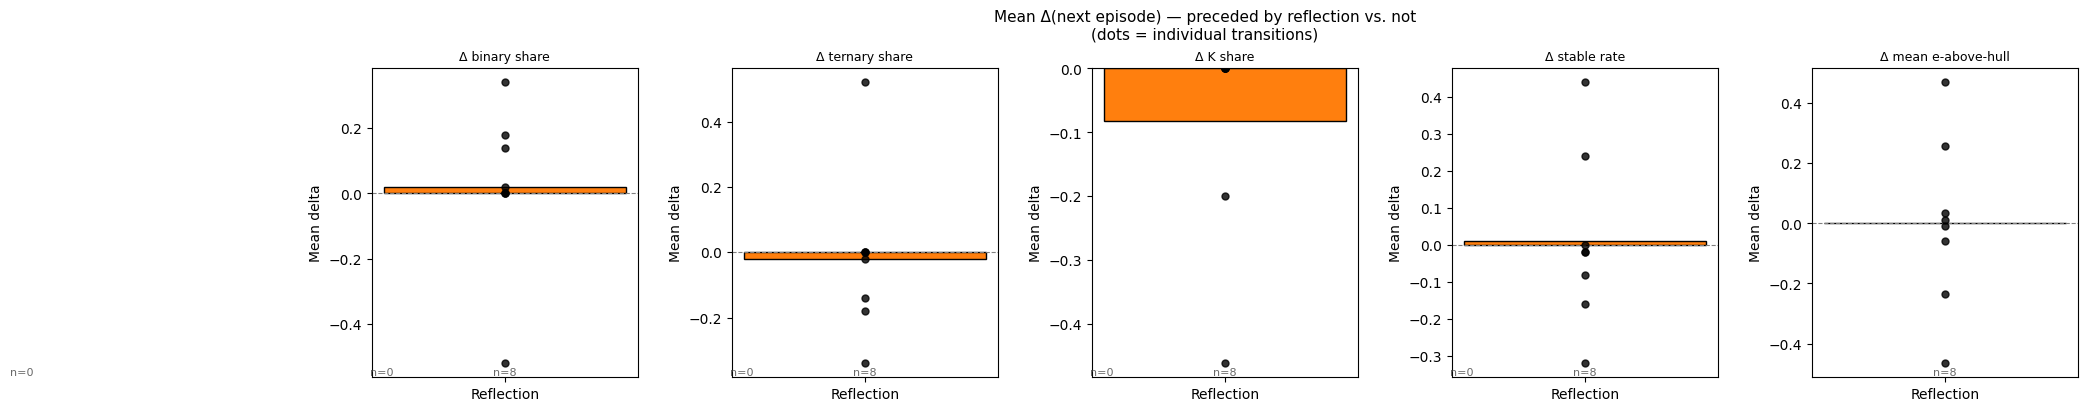

Note: with few episode transitions per system, individual dots carry more weight than bar heights.


In [102]:
episode_mix = (
    df_steps.groupby(['system_id', 'episode_id'])
    .agg(
        share_contains_K=('reduced_formula', lambda x: np.mean(['K' in str(v) for v in x])),
        share_binary=('arity', lambda x: np.mean(x == 2)),
        share_ternary=('arity', lambda x: np.mean(x == 3)),
        share_quaternary=('arity', lambda x: np.mean(x == 4)),
        stable_rate=('is_stable', 'mean'),
        mean_e_above_hull=('e_above_hull', 'mean'),
    )
    .reset_index()
)

follow = sig_df.merge(episode_mix, on=['system_id', 'episode_id'], how='left')
next_mix = episode_mix.copy()
next_mix['episode_id'] = next_mix['episode_id'] - 1
next_mix = next_mix.rename(columns={c: f'next_{c}' for c in next_mix.columns if c not in ['system_id', 'episode_id']})
follow = follow.merge(next_mix, on=['system_id', 'episode_id'], how='left')

delta_spec = {
    'share_contains_K': 'delta_next_share_contains_K',
    'share_binary':      'delta_next_share_binary',
    'share_ternary':     'delta_next_share_ternary',
    'share_quaternary':  'delta_next_share_quaternary',
    'stable_rate':       'delta_next_stable_rate',
    'mean_e_above_hull': 'delta_next_mean_e_above_hull',
}
for col, dcol in delta_spec.items():
    follow[dcol] = follow[f'next_{col}'] - follow[col]

all_delta_cols = list(delta_spec.values())
has_next = follow[all_delta_cols[0]].notna()

# ── Baseline: typical episode-to-episode drift ───────────────────────────────
print("=== Baseline episode-to-episode drift (all transitions, both systems) ===")
display(follow[has_next][all_delta_cols].agg(['mean', 'std']).round(3))

# ── Per-episode delta table ───────────────────────────────────────────────────
display_cols = ['system_id', 'episode_id', 'has_reflection'] + all_delta_cols
display(follow[display_cols].round(3))

# ── Reflection present vs. absent: mean delta on key metrics ─────────────────
valid = follow[has_next]
delta_metrics = [
    ('delta_next_share_binary',      'Δ binary share'),
    ('delta_next_share_ternary',     'Δ ternary share'),
    ('delta_next_share_contains_K',  'Δ K share'),
    ('delta_next_stable_rate',       'Δ stable rate'),
    ('delta_next_mean_e_above_hull', 'Δ mean e-above-hull'),
]

fig, axes = plt.subplots(1, len(delta_metrics), figsize=(18, 4), constrained_layout=True)
fig.suptitle('Mean Δ(next episode) — preceded by reflection vs. not\n(dots = individual transitions)', fontsize=11)

for ax, (dcol, label) in zip(axes, delta_metrics):
    groups = {False: valid[valid['has_reflection'] == False][dcol].dropna(),
              True:  valid[valid['has_reflection'] == True][dcol].dropna()}
    means  = [groups[False].mean(), groups[True].mean()]
    ax.bar(['No reflection', 'Reflection'], means, color=['tab:blue', 'tab:orange'], edgecolor='black', width=0.5)
    for xi, vals in enumerate([groups[False].values, groups[True].values]):
        ax.scatter([xi] * len(vals), vals, color='black', zorder=5, s=25, alpha=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('Mean delta')
    for xi, g in enumerate([groups[False], groups[True]]):
        ax.text(xi, ax.get_ylim()[0], f'n={len(g)}', ha='center', va='bottom', fontsize=8, color='dimgray')

plt.show()
print("Note: with few episode transitions per system, individual dots carry more weight than bar heights.")


## 2) Family Focus Metrics (Composition Families + n-ary Focus)

In [103]:
family_episode = (
    df_steps.groupby(['system_id', 'episode_id', 'family'])
    .agg(
        queries=('query_idx', 'count'),
        stable_hits=('is_stable', 'sum'),
        stable_rate=('is_stable', 'mean'),
        mean_e_above_hull=('e_above_hull', 'mean'),
    )
    .reset_index()
)
family_episode['query_share'] = family_episode.groupby(['system_id', 'episode_id'])['queries'].transform(lambda s: s / s.sum())

top_family = (
    family_episode
    .sort_values(['system_id', 'episode_id', 'query_share'], ascending=[True, True, False])
    .groupby(['system_id', 'episode_id'])
    .head(5)
)
print('Top families by query share per episode:')
display(top_family)


Top families by query share per episode:


,system_id,episode_id,family,queries,stable_hits,stable_rate,mean_e_above_hull,query_share
1,Au-K-Tb,0,Au-K-Tb,26,0,0.000000,0.616518,0.52
2,Au-K-Tb,0,Au-Tb,17,2,0.117647,1.021631,0.34
0,Au-K-Tb,0,Au-K,7,0,0.000000,0.698505,0.14
5,Au-K-Tb,1,Au-Tb,40,22,0.550000,0.338634,0.80
4,Au-K-Tb,1,Au-K-Tb,9,2,0.222222,0.148265,0.18
3,Au-K-Tb,1,Au-K,1,0,0.000000,0.151683,0.02
6,Au-K-Tb,2,Au-Tb,50,16,0.320000,0.557197,1.00
7,Au-K-Tb,3,Au-Tb,50,28,0.560000,0.321162,1.00
8,Au-K-Tb,4,Au-Tb,50,12,0.240000,0.789596,1.00
10,Mg-Sn-Sr,0,Mg-Sn-Sr,24,10,0.416667,0.172375,0.48


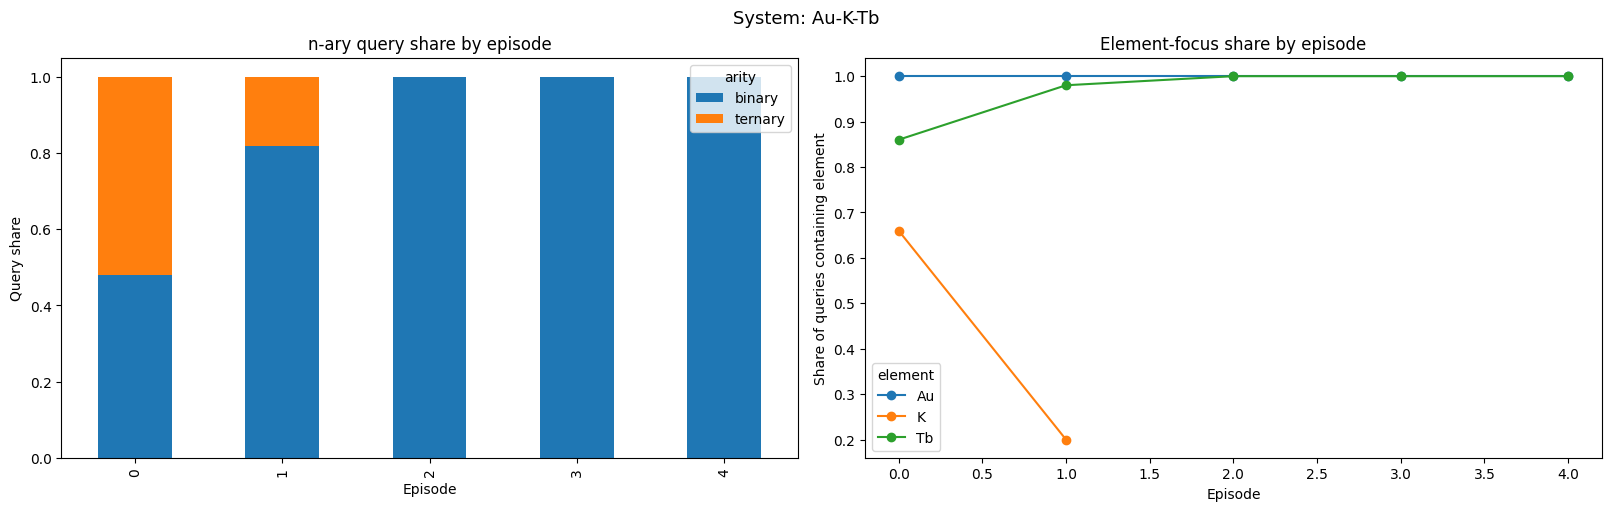

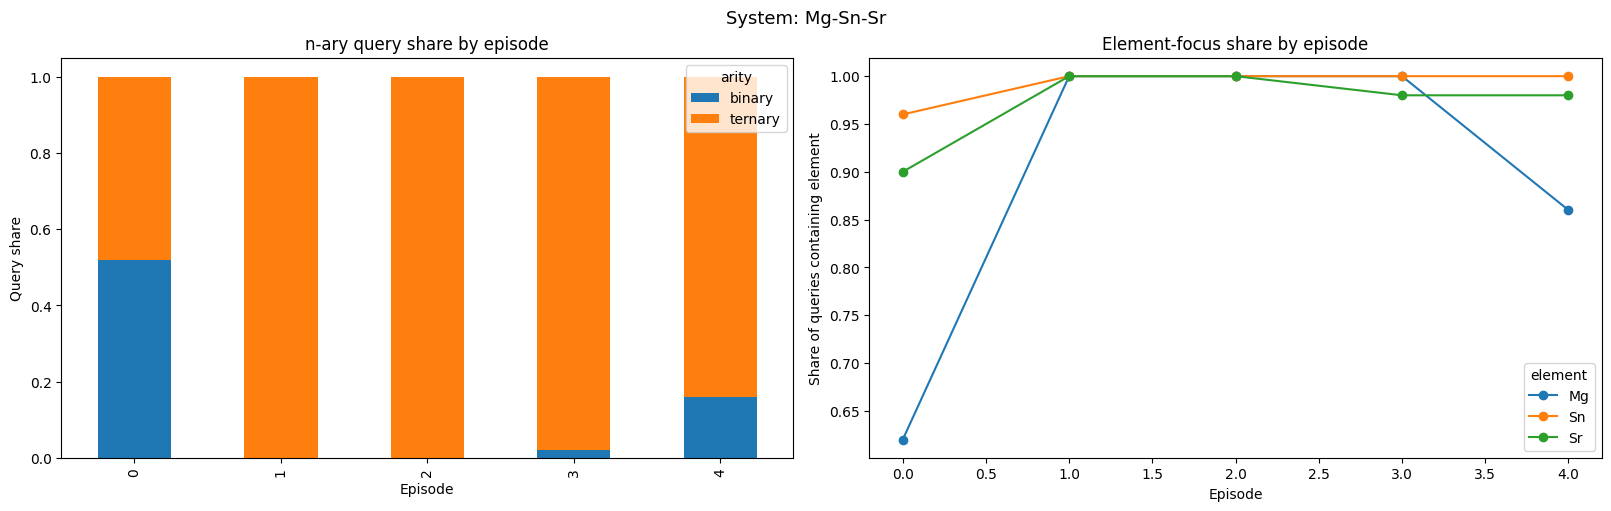

In [104]:
arity_episode = (
    df_steps.groupby(['system_id', 'episode_id', 'arity_label'])
    .size()
    .rename('queries')
    .reset_index()
)
arity_episode['share'] = arity_episode.groupby(['system_id', 'episode_id'])['queries'].transform(lambda s: s / s.sum())

element_rows = []
for (system_id, ep), g in df_steps.groupby(['system_id', 'episode_id']):
    count = Counter()
    for formula in g['reduced_formula']:
        for e in parse_formula(str(formula)).keys():
            count[e] += 1
    total = len(g)
    for e, c in count.items():
        element_rows.append({
            'system_id': system_id,
            'episode_id': ep,
            'element': e,
            'share_of_queries_containing_element': c / total if total else np.nan,
        })
df_element = pd.DataFrame(element_rows)

for system_id in sorted(df_steps['system_id'].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    fig.suptitle(f'System: {system_id}', fontsize=13)

    arity_pivot = (
        arity_episode[arity_episode['system_id'] == system_id]
        .pivot_table(index='episode_id', columns='arity_label', values='share', aggfunc='mean', fill_value=0)
        .sort_index()
    )
    arity_pivot.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title('n-ary query share by episode')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Query share')
    axes[0].legend(title='arity')

    sys_elements = df_element[df_element['system_id'] == system_id]
    for element, g in sys_elements.groupby('element'):
        gg = g.sort_values('episode_id')
        axes[1].plot(
            gg['episode_id'],
            gg['share_of_queries_containing_element'],
            marker='o',
            label=element,
        )
    axes[1].set_title('Element-focus share by episode')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Share of queries containing element')
    axes[1].legend(title='element')

    plt.show()


## 3) Exploration vs Exploitation and New-Family Introduction

In [105]:
required_bm_cols = [
    'bm_num_new_families',
    'bm_new_families_cumulative',
    'bm_selected_family_is_new',
    'bm_queries_since_last_new_family',
    'bm_explore_vs_exploit_ratio',
    'bm_new_family_generation_share',
    'bm_selection_new_composition_rate',
    'bm_recent_yield_novel_stable_rate_last10',
    'bm_buffer_churn_addition_rate',
    'bm_buffer_churn_duplicate_rejection_rate',
]
missing = [c for c in required_bm_cols if c not in df_steps.columns]
print('Missing behavior columns:', missing if missing else 'None')


Missing behavior columns: None


In [106]:
df_explore = df_steps.copy()
df_explore['new_family_event'] = df_explore['bm_num_new_families'].fillna(0) > 0

episode_explore = (
    df_explore.groupby(['system_id', 'episode_id'])
    .agg(
        total_queries=('query_idx', 'count'),
        new_family_event_count=('new_family_event', 'sum'),
        total_new_families=('bm_num_new_families', 'sum'),
        final_new_families_cumulative=('bm_new_families_cumulative', 'max'),
        last_new_family_query=('query_idx', lambda s: s[df_explore.loc[s.index, 'new_family_event']].max() if df_explore.loc[s.index, 'new_family_event'].any() else -1),
        mean_explore_vs_exploit=('bm_explore_vs_exploit_ratio', 'mean'),
    )
    .reset_index()
)
episode_explore['fraction_queries_with_new_family'] = episode_explore['new_family_event_count'] / episode_explore['total_queries']
display(episode_explore)


,system_id,episode_id,total_queries,new_family_event_count,total_new_families,final_new_families_cumulative,last_new_family_query,mean_explore_vs_exploit,fraction_queries_with_new_family
0,Au-K-Tb,0,50,2,14.0,14.0,1,0.560807,0.04
1,Au-K-Tb,1,50,10,38.0,30.0,45,0.552100,0.20
2,Au-K-Tb,2,50,2,7.0,7.0,17,0.267220,0.04
3,Au-K-Tb,3,50,14,30.0,15.0,47,0.268710,0.28
4,Au-K-Tb,4,50,6,12.0,7.0,21,0.293353,0.12
5,Mg-Sn-Sr,0,50,20,79.0,29.0,48,0.726700,0.40
6,Mg-Sn-Sr,1,50,11,60.0,34.0,34,0.756619,0.22
7,Mg-Sn-Sr,2,50,16,49.0,33.0,49,0.598355,0.32
8,Mg-Sn-Sr,3,50,11,56.0,42.0,34,1.478576,0.22
9,Mg-Sn-Sr,4,50,10,44.0,37.0,42,1.005374,0.20


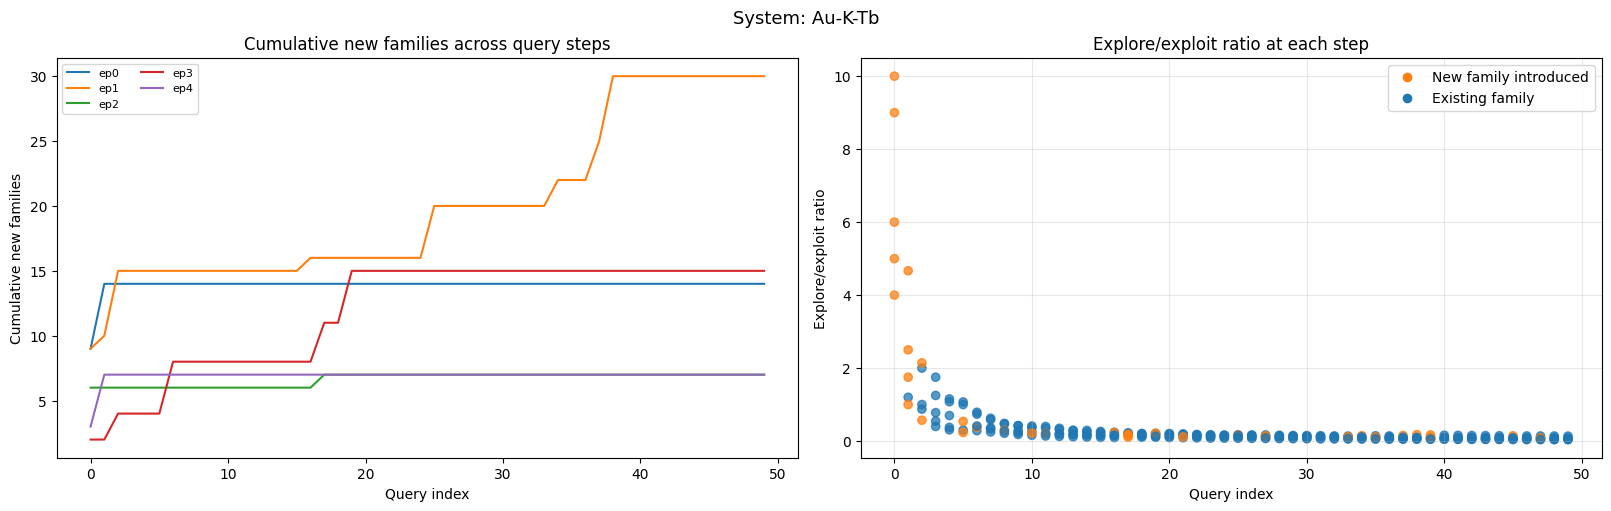

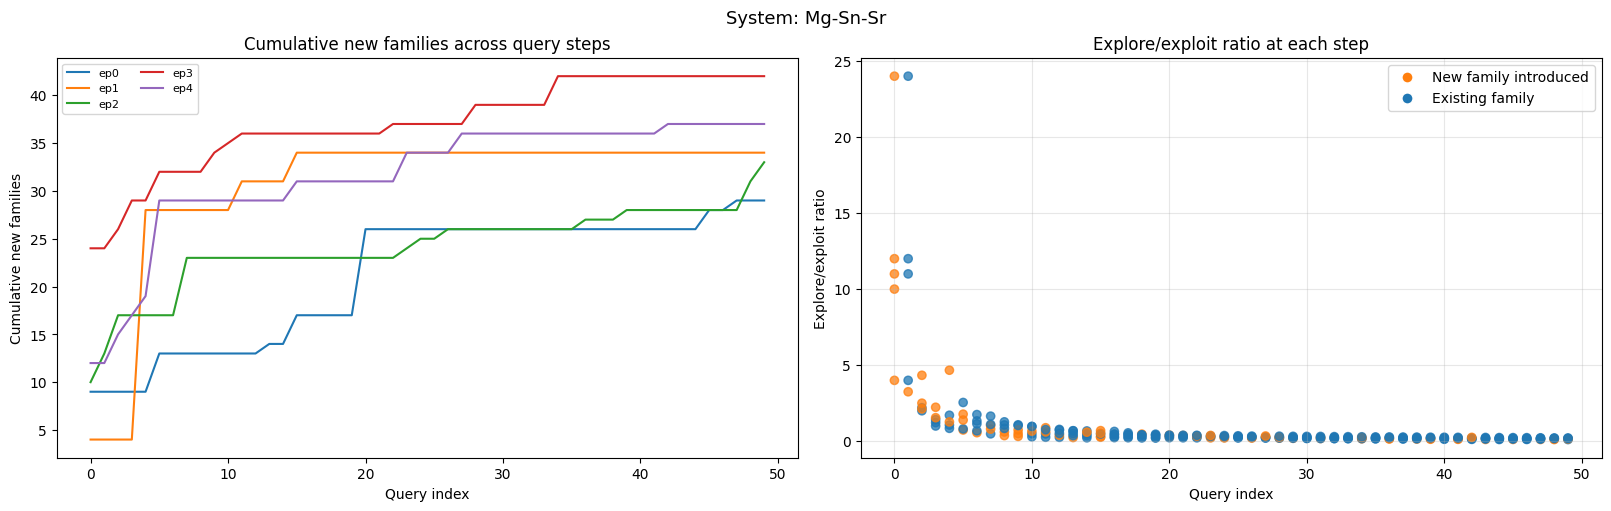

In [107]:
color_map = {True: 'tab:orange', False: 'tab:blue'}

for system_id in sorted(df_explore['system_id'].unique()):
    sys_df = df_explore[df_explore['system_id'] == system_id]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    fig.suptitle(f'System: {system_id}', fontsize=13)

    for ep, g in sys_df.groupby('episode_id'):
        axes[0].plot(g['query_idx'], g['bm_new_families_cumulative'], label=f'ep{ep}')
    axes[0].set_title('Cumulative new families across query steps')
    axes[0].set_xlabel('Query index')
    axes[0].set_ylabel('Cumulative new families')
    axes[0].legend(fontsize=8, ncol=2)

    colors = [color_map[v] for v in sys_df['new_family_event']]
    axes[1].scatter(
        sys_df['query_idx'],
        sys_df['bm_explore_vs_exploit_ratio'],
        c=colors,
        alpha=0.75,
    )
    axes[1].set_title('Explore/exploit ratio at each step')
    axes[1].set_xlabel('Query index')
    axes[1].set_ylabel('Explore/exploit ratio')
    axes[1].grid(True, alpha=0.3)

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=8, label='New family introduced'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='Existing family'),
    ]
    axes[1].legend(handles=legend_handles)

    plt.show()
    

In [108]:
compare_cols = [
    'bm_explore_vs_exploit_ratio',
    'bm_queries_since_last_new_family',
    'bm_new_family_generation_share',
    'bm_selection_new_composition_rate',
    'bm_recent_yield_novel_stable_rate_last10',
    'bm_buffer_churn_addition_rate',
    'bm_buffer_churn_duplicate_rejection_rate',
]

new_df = df_explore[df_explore['new_family_event']]
old_df = df_explore[~df_explore['new_family_event']]

comparison = pd.DataFrame({
    'new_family_event_mean': new_df[compare_cols].mean(),
    'no_new_family_mean': old_df[compare_cols].mean(),
})
comparison['diff'] = comparison['new_family_event_mean'] - comparison['no_new_family_mean']
comparison = comparison.sort_values('diff', ascending=False)
display(comparison)


,new_family_event_mean,no_new_family_mean,diff
bm_explore_vs_exploit_ratio,1.523784,0.427047,1.096736
bm_new_family_generation_share,0.703232,0.000000,0.703232
bm_selection_new_composition_rate,0.705985,0.557756,0.148230
bm_buffer_churn_duplicate_rejection_rate,0.309245,0.253382,0.055864
bm_recent_yield_novel_stable_rate_last10,0.338375,0.338428,-0.000053
bm_buffer_churn_addition_rate,0.689998,0.744134,-0.054137
bm_queries_since_last_new_family,0.000000,8.419598,-8.419598


## 3b) What Drives New Family Introduction?

We compute three lagged signals that could precede a new-family event and compare
their values at event vs. non-event steps:

1. **`rolling_mean_e_above_hull_5`** — rolling mean e_above_hull of the previous 5 steps (shifted by 1).
   If the agent is dissatisfied with recent oracle returns, this will be high before exploration bursts.
2. **`cum_family_mean_ehull`** — cumulative mean e_above_hull of all prior queries to the *same* family.
   A rising value means the current family is consistently failing, which should motivate switching.
3. **`bm_selection_max_same_composition_streak`** — how many consecutive queries have been to the same
   composition. Long streaks suggest exploitation lock-in before a forced break-out.

We also visualize these signals over query steps, with new-family events marked.

In [109]:
# ── Compute lagged signals ────────────────────────────────────────────────────
ROLLING_WINDOW = 5

df_signals = df_explore.sort_values(['system_id', 'episode_id', 'query_idx']).copy()

# 1. Rolling mean e_above_hull of previous ROLLING_WINDOW steps (lagged by 1 so it's truly "before" this step)
df_signals['rolling_mean_e_above_hull_5'] = (
    df_signals.groupby(['system_id', 'episode_id'])['e_above_hull']
    .transform(lambda s: s.shift(1).rolling(ROLLING_WINDOW, min_periods=1).mean())
)

# 2. Cumulative mean e_above_hull of all prior queries to the same family (within this episode)
def cumulative_family_mean_ehull(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values('query_idx')
    family_sums: dict[str, float] = {}
    family_counts: dict[str, int] = {}
    result = []
    for _, row in group.iterrows():
        fam = row['family']
        prev_count = family_counts.get(fam, 0)
        result.append(family_sums.get(fam, 0.0) / prev_count if prev_count > 0 else np.nan)
        ehull = row['e_above_hull'] if pd.notna(row['e_above_hull']) else 0.0
        family_sums[fam] = family_sums.get(fam, 0.0) + ehull
        family_counts[fam] = prev_count + 1
    return pd.Series(result, index=group.index)

df_signals['cum_family_mean_ehull'] = (
    df_signals.groupby(['system_id', 'episode_id'], group_keys=False)
    .apply(cumulative_family_mean_ehull)
)

# ── Extend the comparison table with the new lagged signals ──────────────────
extended_compare_cols = [
    'rolling_mean_e_above_hull_5',
    'cum_family_mean_ehull',
    'bm_selection_max_same_composition_streak',
    'e_above_hull',
    'bm_recent_yield_novel_stable_rate_last10',
    'bm_buffer_churn_duplicate_rejection_rate',
]

new_ev  = df_signals[df_signals['new_family_event']]
no_ev   = df_signals[~df_signals['new_family_event']]

ext_comparison = pd.DataFrame({
    'new_family_event_mean': new_ev[extended_compare_cols].mean(),
    'no_new_family_mean':    no_ev[extended_compare_cols].mean(),
})
ext_comparison['diff']        = ext_comparison['new_family_event_mean'] - ext_comparison['no_new_family_mean']
ext_comparison['diff_pct']    = (ext_comparison['diff'] / ext_comparison['no_new_family_mean'].abs() * 100).round(1)
ext_comparison = ext_comparison.sort_values('diff', ascending=False)

print('=== Lagged signal comparison: new-family-event steps vs. all other steps ===')
display(ext_comparison.round(4))
print()
print('Interpretation guide:')
print('  rolling_mean_e_above_hull_5 > 0  →  agent was getting poor oracle returns before exploring')
print('  cum_family_mean_ehull       > 0  →  the current family had a bad track record before switching')
print('  streak higher at events         →  agent breaks out after getting stuck on one composition')


=== Lagged signal comparison: new-family-event steps vs. all other steps ===


/var/folders/v5/tqkscwv970l_r164vw66r3800000gn/T/ipykernel_30950/718181220.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cumulative_family_mean_ehull)


,new_family_event_mean,no_new_family_mean,diff,diff_pct
bm_buffer_churn_duplicate_rejection_rate,0.3092,0.2534,0.0559,22.0
bm_recent_yield_novel_stable_rate_last10,0.3384,0.3384,-0.0001,-0.0
e_above_hull,0.2271,0.3672,-0.1401,-38.2
rolling_mean_e_above_hull_5,0.1770,0.3591,-0.1822,-50.7
cum_family_mean_ehull,0.1756,0.3642,-0.1886,-51.8
bm_selection_max_same_composition_streak,1.9020,2.2136,-0.3116,-14.1



Interpretation guide:
  rolling_mean_e_above_hull_5 > 0  →  agent was getting poor oracle returns before exploring
  cum_family_mean_ehull       > 0  →  the current family had a bad track record before switching
  streak higher at events         →  agent breaks out after getting stuck on one composition


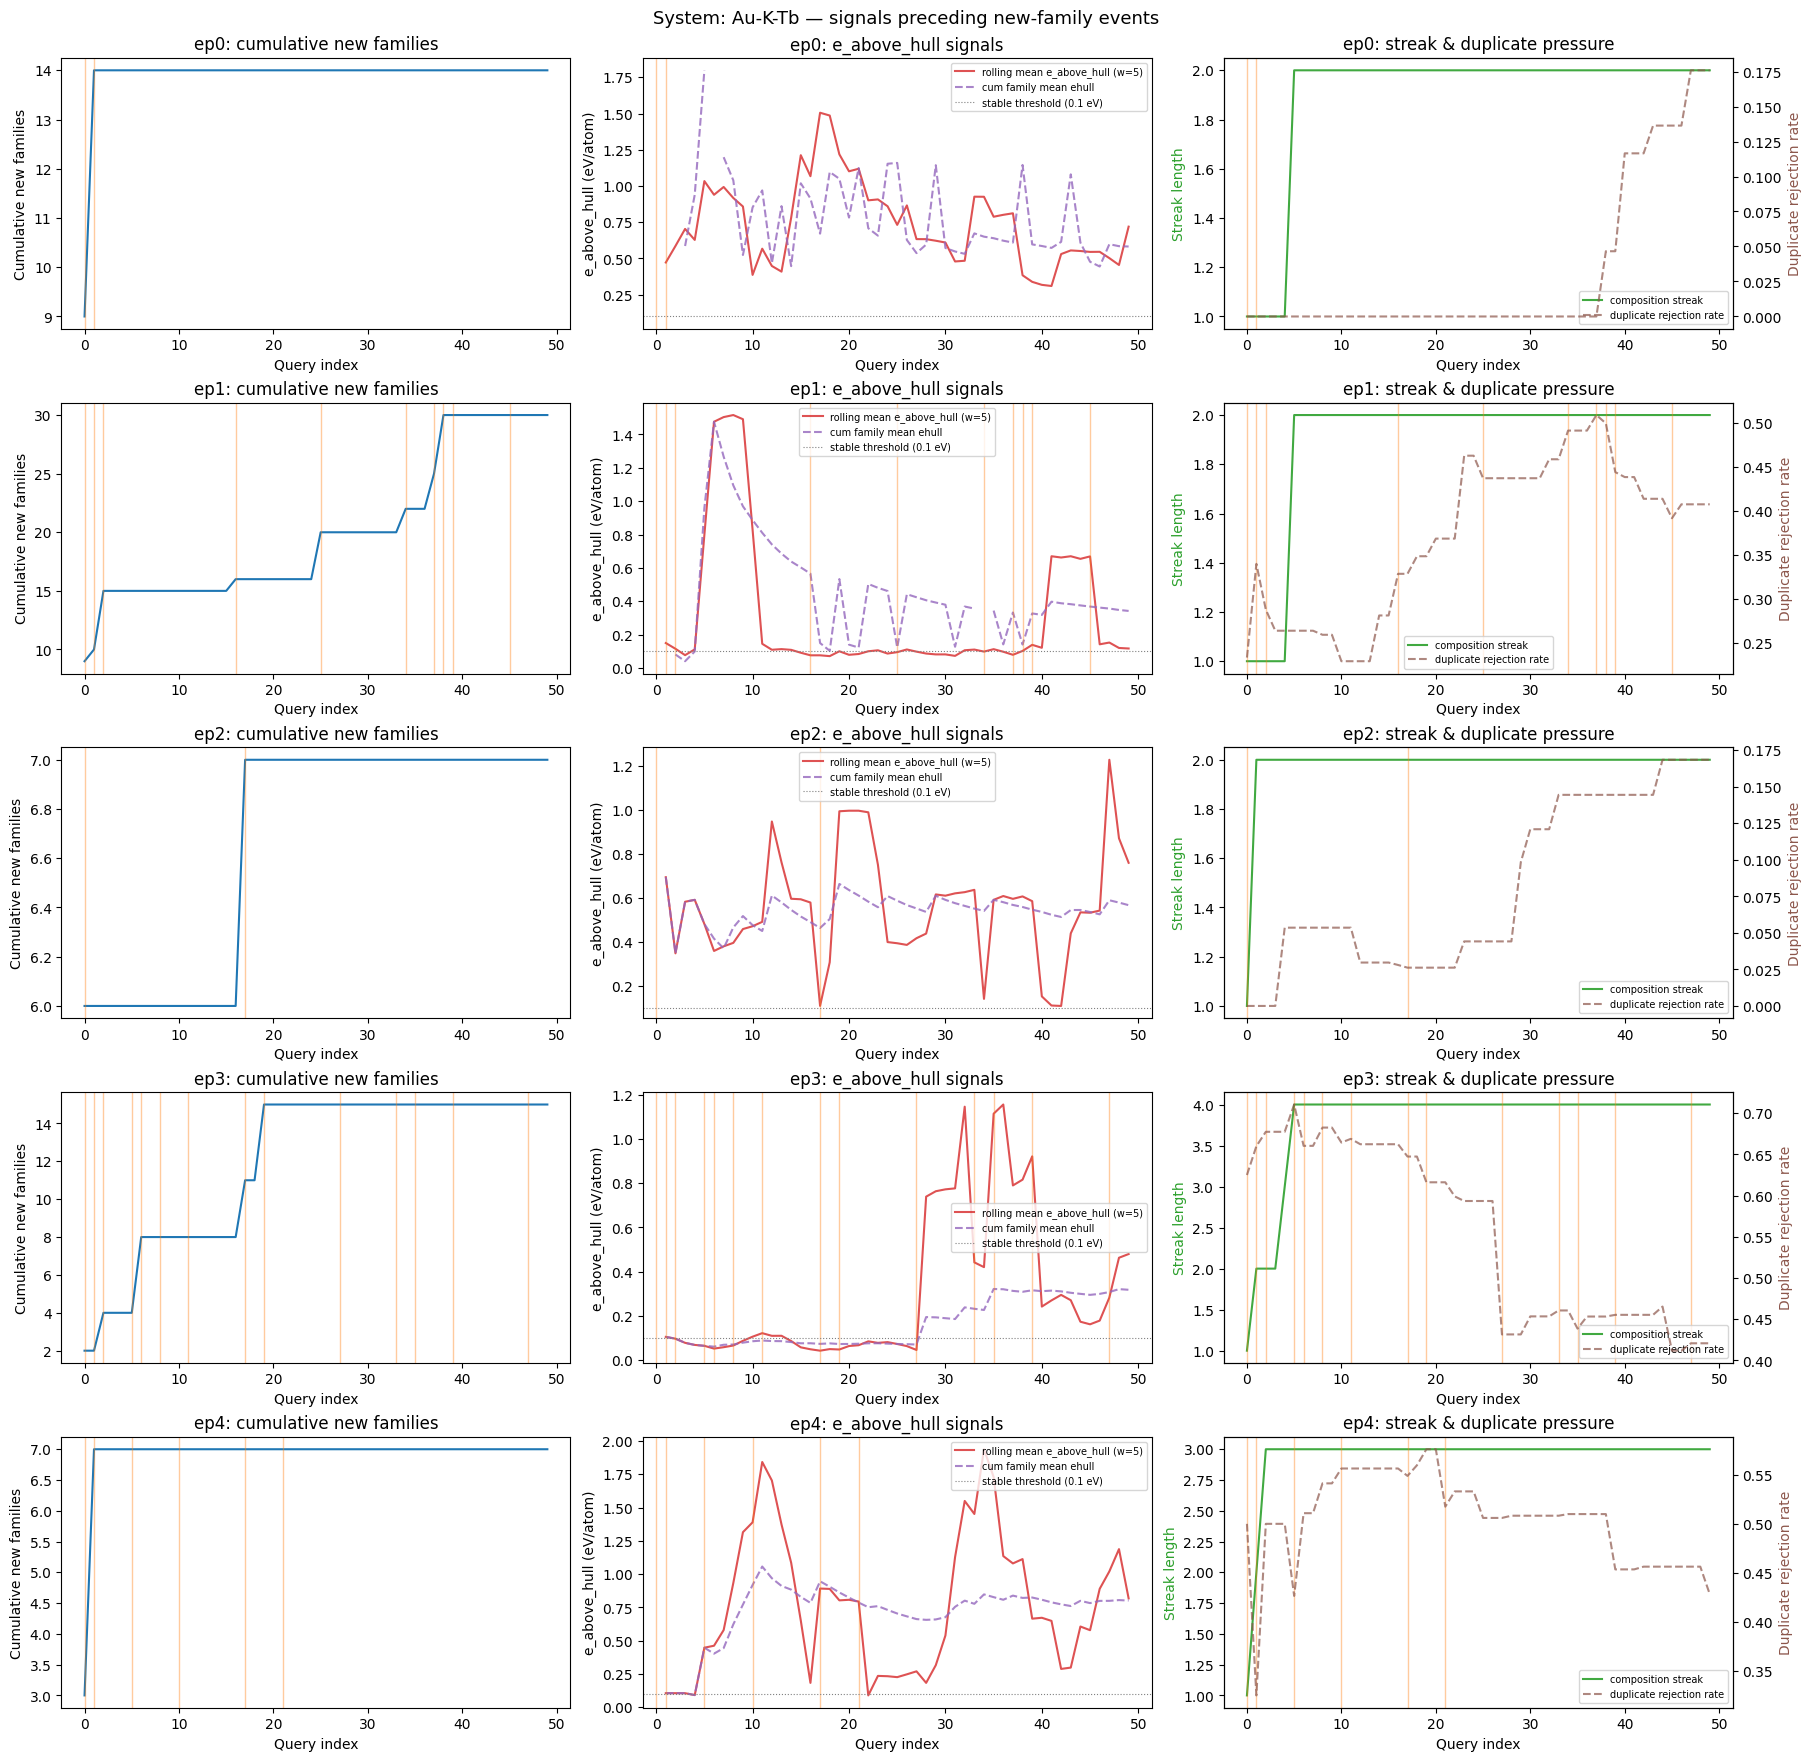

Orange vertical lines mark steps where a new family was introduced.


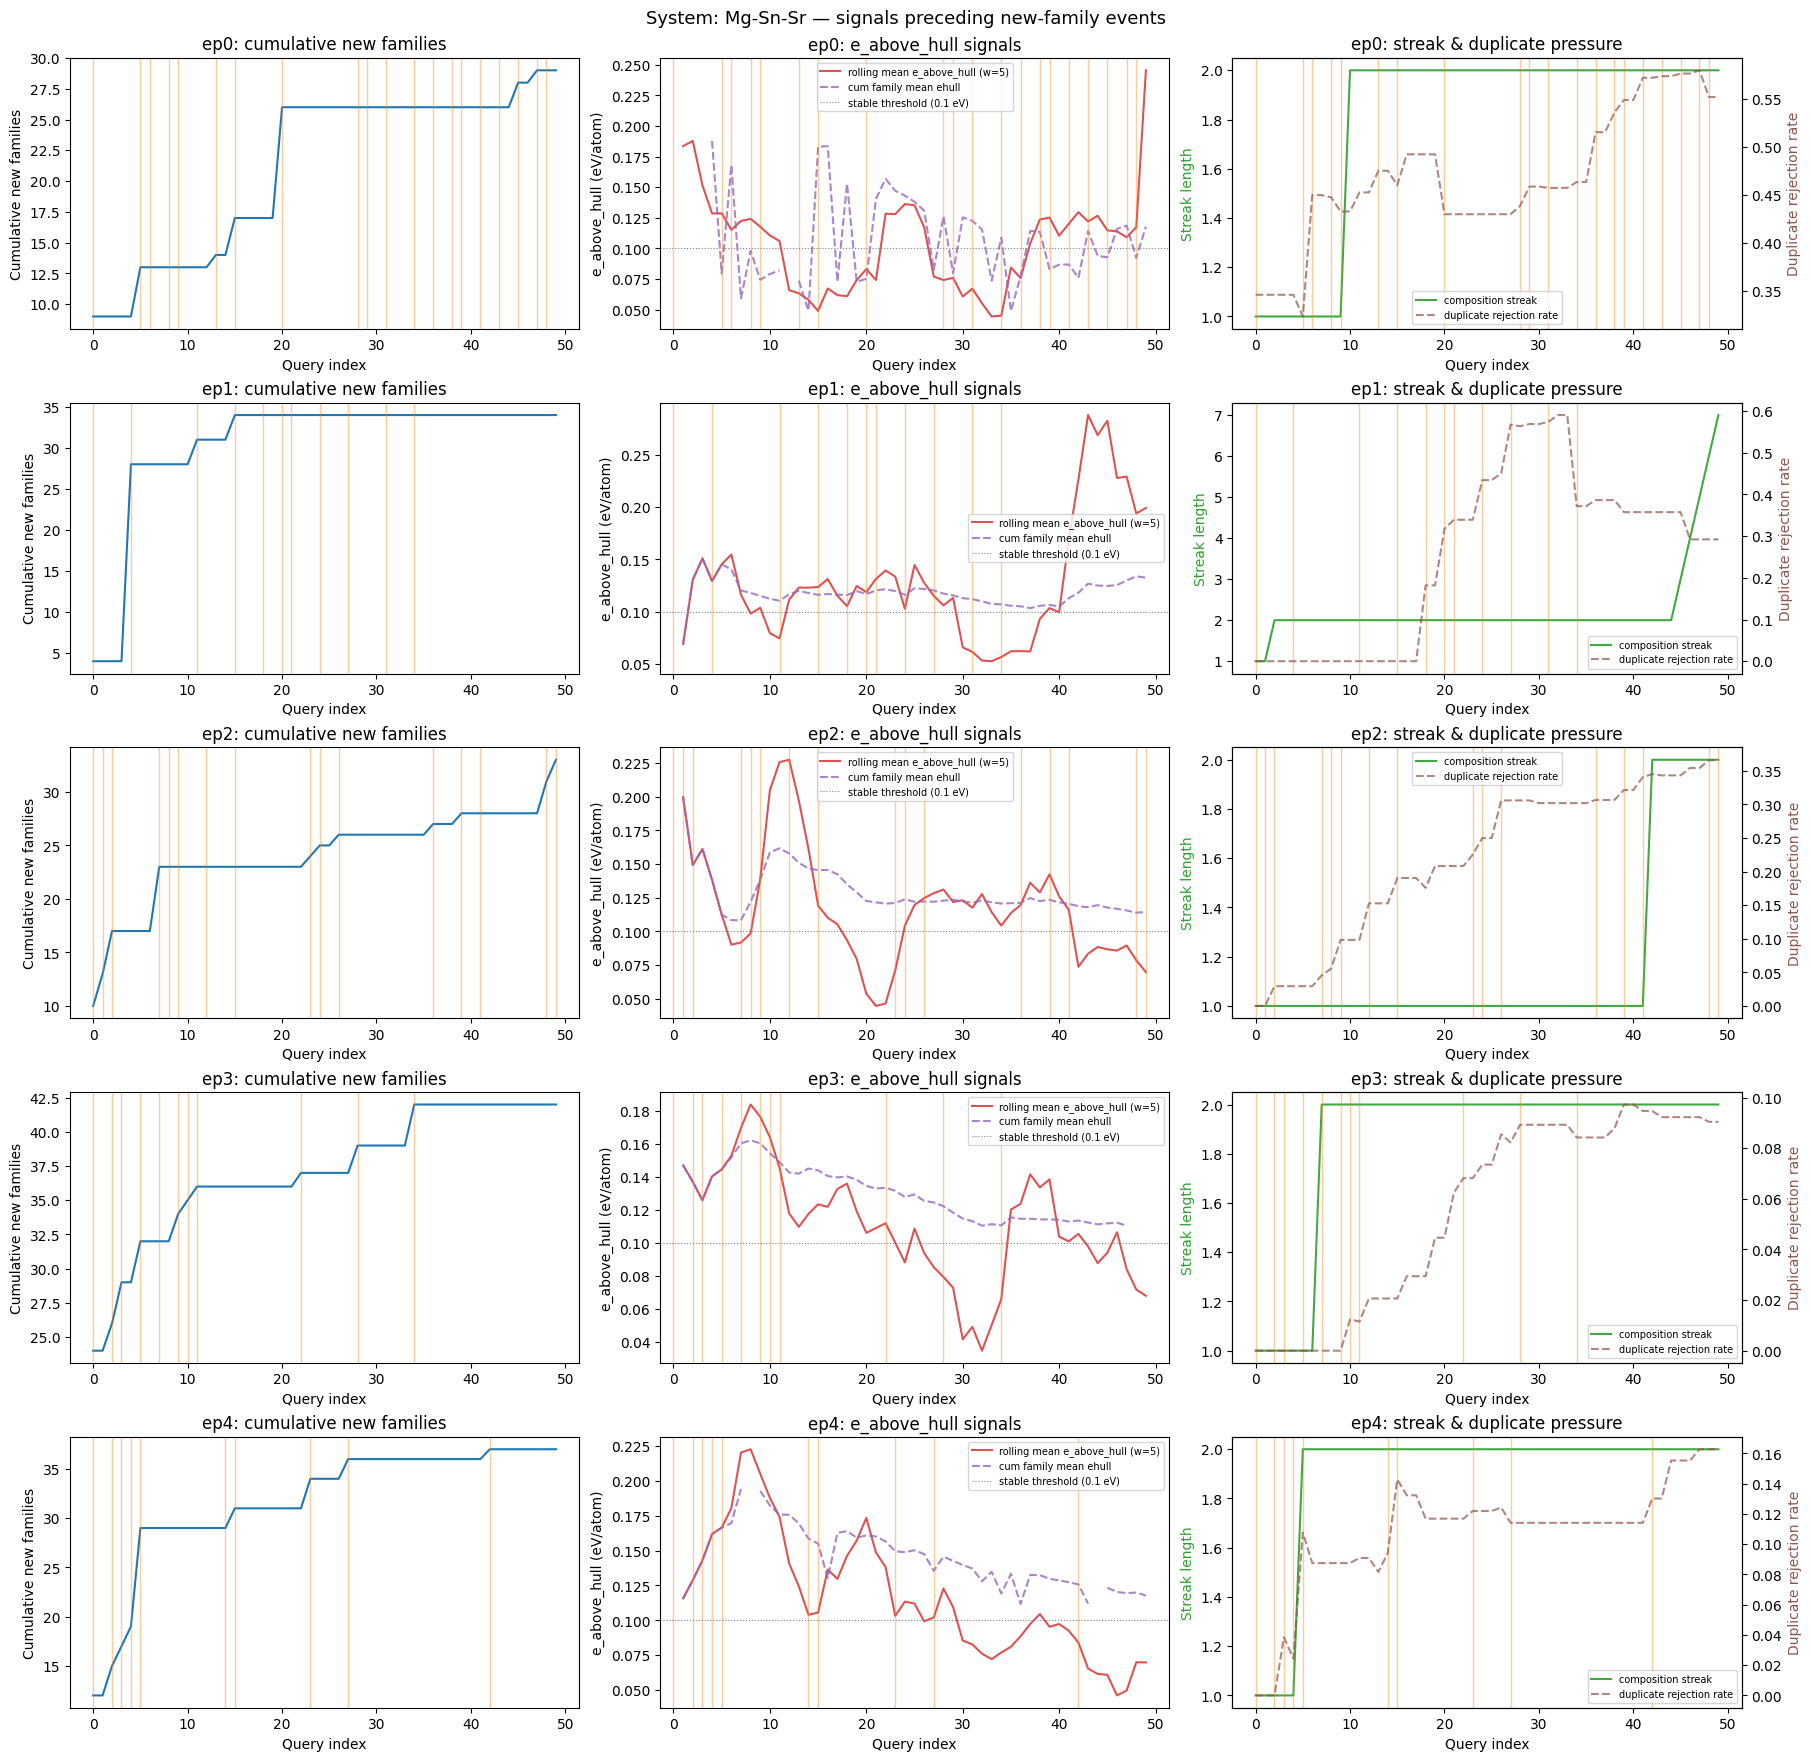

Orange vertical lines mark steps where a new family was introduced.


In [110]:
# ── Per-episode overlay: rolling e_above_hull + streak vs. cumulative new families ──
for system_id in sorted(df_signals['system_id'].unique()):
    sys_df = df_signals[df_signals['system_id'] == system_id]
    episodes = sorted(sys_df['episode_id'].unique())

    fig, axes = plt.subplots(len(episodes), 3, figsize=(18, 3.5 * len(episodes)), constrained_layout=True)
    fig.suptitle(f'System: {system_id} — signals preceding new-family events', fontsize=13)

    for row_i, ep in enumerate(episodes):
        ep_df = sys_df[sys_df['episode_id'] == ep].sort_values('query_idx')
        event_steps = ep_df[ep_df['new_family_event']]['query_idx'].values

        ax0, ax1, ax2 = axes[row_i]
        ep_label = f'ep{ep}'

        # Panel 0: cumulative new families with event markers
        ax0.plot(ep_df['query_idx'], ep_df['bm_new_families_cumulative'], color='tab:blue')
        for es in event_steps:
            ax0.axvline(es, color='tab:orange', alpha=0.4, linewidth=1)
        ax0.set_title(f'{ep_label}: cumulative new families')
        ax0.set_xlabel('Query index')
        ax0.set_ylabel('Cumulative new families')

        # Panel 1: rolling mean e_above_hull + cumulative family mean ehull
        ax1.plot(ep_df['query_idx'], ep_df['rolling_mean_e_above_hull_5'],
                 label=f'rolling mean e_above_hull (w={ROLLING_WINDOW})', color='tab:red', alpha=0.8)
        ax1.plot(ep_df['query_idx'], ep_df['cum_family_mean_ehull'],
                 label='cum family mean ehull', color='tab:purple', alpha=0.8, linestyle='--')
        for es in event_steps:
            ax1.axvline(es, color='tab:orange', alpha=0.4, linewidth=1)
        ax1.axhline(0.1, color='gray', linestyle=':', linewidth=0.8, label='stable threshold (0.1 eV)')
        ax1.set_title(f'{ep_label}: e_above_hull signals')
        ax1.set_xlabel('Query index')
        ax1.set_ylabel('e_above_hull (eV/atom)')
        ax1.legend(fontsize=7)

        # Panel 2: composition streak + duplicate rejection rate
        ax2_twin = ax2.twinx()
        ax2.plot(ep_df['query_idx'], ep_df['bm_selection_max_same_composition_streak'],
                 label='composition streak', color='tab:green', alpha=0.9)
        ax2_twin.plot(ep_df['query_idx'], ep_df['bm_buffer_churn_duplicate_rejection_rate'],
                 label='duplicate rejection rate', color='tab:brown', alpha=0.7, linestyle='--')
        for es in event_steps:
            ax2.axvline(es, color='tab:orange', alpha=0.4, linewidth=1)
        ax2.set_title(f'{ep_label}: streak & duplicate pressure')
        ax2.set_xlabel('Query index')
        ax2.set_ylabel('Streak length', color='tab:green')
        ax2_twin.set_ylabel('Duplicate rejection rate', color='tab:brown')
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

    plt.show()
    print(f'Orange vertical lines mark steps where a new family was introduced.')


In [ ]:
# --- Element coverage + composition concentration across episodes, per system ---
elem_ratio_cols = [c for c in df_steps.columns if c.startswith('bm_element_arg_presence_ratio_')]

# Pre-compute: for each (system_id, episode_id), find the most-queried reduced_formula
# and record the step indices at which it was queried
top_comp_info = {}
for (system_id, episode_id), g in df_steps.groupby(['system_id', 'episode_id']):
    counts = g['reduced_formula'].value_counts()
    top_comp = counts.index[0]
    steps = sorted(g[g['reduced_formula'] == top_comp]['query_idx'].tolist())
    top_comp_info[(system_id, episode_id)] = (top_comp, steps)

if elem_ratio_cols:
    last_steps = df_steps.sort_values('query_idx').groupby(['system_id', 'episode_id']).tail(1)
    print("=== Element Coverage (presence ratio from tool args) ===")
    for system_id, sys_group in last_steps.groupby('system_id'):
        system_elements = sorted(set(system_id.split('-')))
        system_elem_cols = [c for c in elem_ratio_cols if any(c.endswith(f'_{e}') for e in system_elements)]
        if not system_elem_cols:
            print(f"\n{system_id}: no element ratio columns found")
            continue
        print(f"\n--- {system_id} ---")
        coverage = sys_group[['episode_id'] + system_elem_cols].copy()
        coverage.columns = ['episode_id'] + [c.replace('bm_element_arg_presence_ratio_', '') for c in system_elem_cols]

        # Max queries on any single composition = top1_share * total
        if 'bm_selection_total' in sys_group.columns and 'bm_selection_top1_share' in sys_group.columns:
            coverage['total_queries'] = sys_group['bm_selection_total'].values
            coverage['unique_compositions'] = sys_group['bm_selection_unique_count'].values.astype(int)
            coverage['max_queries_per_comp'] = (
                sys_group['bm_selection_top1_share'].values * sys_group['bm_selection_total'].values
            ).round().astype(int)

        # Top composition and its query step indices
        coverage['top_comp'] = coverage['episode_id'].map(
            lambda ep: top_comp_info.get((system_id, ep), ('?', []))[0]
        )
        coverage['top_comp_steps'] = coverage['episode_id'].map(
            lambda ep: str(top_comp_info.get((system_id, ep), ('?', []))[1])
        )

        coverage = coverage.sort_values('episode_id').reset_index(drop=True)
        display(coverage.round(3))

        for col in [c for c in coverage.columns if c not in (
            'episode_id', 'total_queries', 'unique_compositions',
            'max_queries_per_comp', 'top_comp', 'top_comp_steps'
        )]:
            low_eps = coverage[coverage[col] < 0.1]['episode_id'].tolist()
            if low_eps:
                print(f"  ⚠ {col} near-zero in episodes: {low_eps}")
else:
    print("No element_arg_presence_ratio columns found in behavior metrics.")

# Build sig_df: just episode-level reflection presence, no signal parsing
sig_df = df_reflections[['system_id', 'episode_id', 'has_reflection']].copy()


=== Element Coverage (presence ratio from tool args) ===

--- Au-K-Tb ---


,episode_id,Au,K,Tb,total_queries,unique_compositions,max_queries_per_comp,top_comp,top_comp_steps
0,0,1.0,0.682,0.838,50.0,14,6,Au1 K2 Tb1,"[0, 34, 37, 39, 41, 47]"
1,1,1.0,0.150,0.986,50.0,21,6,Au2 Tb1,"[1, 12, 22, 32, 37, 39]"
2,2,1.0,0.000,1.000,50.0,7,11,Au2 Tb1,"[0, 1, 11, 13, 14, 21, 22, 26, 29, 40, 48]"
3,3,1.0,0.000,1.000,50.0,13,8,Au3 Tb1,"[2, 3, 4, 5, 28, 41, 45, 46]"
4,4,1.0,0.000,1.000,50.0,6,14,Au1 Tb2,"[0, 1, 2, 5, 9, 10, 15, 17, 19, 23, 24, 30, 31, 37]"


  ⚠ K near-zero in episodes: [2, 3, 4]

--- Mg-Sn-Sr ---


,episode_id,Mg,Sn,Sr,total_queries,unique_compositions,max_queries_per_comp,top_comp,top_comp_steps
0,0,0.623,0.918,0.912,50.0,24,5,Sn1 Sr1,"[9, 10, 19, 39, 48]"
1,1,1.000,1.000,1.000,50.0,18,15,Mg1 Sn2 Sr1,"[3, 22, 23, 27, 29, 31, 37, 40, 43, 44, 45, 46, 47, 48, 49]"
2,2,1.000,1.000,1.000,50.0,25,5,Mg1 Sn2 Sr1,"[12, 18, 32, 34, 47]"
3,3,1.000,1.000,0.993,50.0,31,4,Mg3 Sn1 Sr3,"[1, 6, 7, 45]"
4,4,0.883,0.992,0.992,50.0,32,4,Mg1 Sn1 Sr3,"[6, 17, 20, 49]"


## 4) Learning From Mistakes (Episode-to-Episode Family Reallocation)

Heuristic check: families with poor stability in episode `t` should receive less query share in `t+1` if the agent is learning from mistakes.


In [111]:
fam_stats = (
    df_steps.groupby(['system_id', 'episode_id', 'family'])
    .agg(queries=('query_idx', 'count'), mean_ehull=('e_above_hull', 'mean'))
    .reset_index()
)
fam_stats['share'] = fam_stats.groupby(['system_id', 'episode_id'])['queries'].transform(lambda s: s / s.sum())

rows = []
for (system_id, ep), g in fam_stats.groupby(['system_id', 'episode_id']):
    nxt = fam_stats[(fam_stats['system_id'] == system_id) & (fam_stats['episode_id'] == ep + 1)]
    if nxt.empty:
        continue

    nxt_share = dict(zip(nxt['family'], nxt['share']))
    poor = g[(g['queries'] >= 2) & (g['mean_ehull'] > 0.2)]
    good = g[(g['queries'] >= 2) & (g['mean_ehull'] <= 0.1)]

    poor_delta = [nxt_share.get(r['family'], 0.0) - r['share'] for _, r in poor.iterrows()]
    good_delta = [nxt_share.get(r['family'], 0.0) - r['share'] for _, r in good.iterrows()]

    rows.append({
        'system_id': system_id,
        'episode_t': ep,
        'episode_t1': ep + 1,
        'num_poor_families': len(poor_delta),
        'mean_share_delta_poor_families': np.mean(poor_delta) if poor_delta else np.nan,
        'num_good_families': len(good_delta),
        'mean_share_delta_good_families': np.mean(good_delta) if good_delta else np.nan,
    })

df_realloc = pd.DataFrame(rows)
display(df_realloc)


,system_id,episode_t,episode_t1,num_poor_families,mean_share_delta_poor_families,num_good_families,mean_share_delta_good_families
0,Au-K-Tb,0,1,3,0.0,0,NaN
1,Au-K-Tb,1,2,1,0.2,0,NaN
2,Au-K-Tb,2,3,1,0.0,0,NaN
3,Au-K-Tb,3,4,1,0.0,0,NaN
4,Mg-Sn-Sr,0,1,0,NaN,2,-0.07
5,Mg-Sn-Sr,1,2,0,NaN,0,NaN
6,Mg-Sn-Sr,2,3,0,NaN,0,NaN
7,Mg-Sn-Sr,3,4,0,NaN,0,NaN


In [112]:
# ── Reflection presence × family reallocation ────────────────────────────────
# Do episode transitions preceded by a reflection show larger shifts
# away from poor families and toward good ones?

refl_realloc = df_realloc.merge(
    sig_df[['system_id', 'episode_id', 'has_reflection']],
    left_on=['system_id', 'episode_t'],
    right_on=['system_id', 'episode_id'],
    how='left',
).drop(columns=['episode_id'])

display_cols = [
    'system_id', 'episode_t', 'has_reflection',
    'num_poor_families', 'mean_share_delta_poor_families',
    'num_good_families', 'mean_share_delta_good_families',
]
display(refl_realloc[display_cols].round(3))

has_refl = refl_realloc[refl_realloc['has_reflection'] == True]
no_refl  = refl_realloc[refl_realloc['has_reflection'] == False]
print(f"Mean Δ share (poor families) | reflection present : {has_refl['mean_share_delta_poor_families'].mean():+.3f}  (n={len(has_refl)})")
print(f"Mean Δ share (poor families) | no reflection      : {no_refl['mean_share_delta_poor_families'].mean():+.3f}  (n={len(no_refl)})")
print(f"\nMean Δ share (good families) | reflection present : {has_refl['mean_share_delta_good_families'].mean():+.3f}  (n={len(has_refl)})")
print(f"Mean Δ share (good families) | no reflection      : {no_refl['mean_share_delta_good_families'].mean():+.3f}  (n={len(no_refl)})")
print("\nNote: ≤2 transitions per system — treat as illustrative, not conclusive.")


,system_id,episode_t,has_reflection,num_poor_families,mean_share_delta_poor_families,num_good_families,mean_share_delta_good_families
0,Au-K-Tb,0,True,3,0.0,0,NaN
1,Au-K-Tb,1,True,1,0.2,0,NaN
2,Au-K-Tb,2,True,1,0.0,0,NaN
3,Au-K-Tb,3,True,1,0.0,0,NaN
4,Mg-Sn-Sr,0,True,0,NaN,2,-0.07
5,Mg-Sn-Sr,1,True,0,NaN,0,NaN
6,Mg-Sn-Sr,2,True,0,NaN,0,NaN
7,Mg-Sn-Sr,3,True,0,NaN,0,NaN


Mean Δ share (poor families) | reflection present : +0.050  (n=8)
Mean Δ share (poor families) | no reflection      : +nan  (n=0)

Mean Δ share (good families) | reflection present : -0.070  (n=8)
Mean Δ share (good families) | no reflection      : +nan  (n=0)

Note: ≤2 transitions per system — treat as illustrative, not conclusive.


,system_id,episode_id,new_stable_count,stable_discovery_efficiency,stable_fraction
0,Au-K-Tb,0,2,0.04,0.04
1,Au-K-Tb,1,17,0.34,0.48
2,Au-K-Tb,2,13,0.26,0.32
3,Au-K-Tb,3,21,0.42,0.56
4,Au-K-Tb,4,11,0.22,0.24
5,Mg-Sn-Sr,0,25,0.50,0.58
6,Mg-Sn-Sr,1,21,0.42,0.50
7,Mg-Sn-Sr,2,21,0.42,0.48
8,Mg-Sn-Sr,3,21,0.42,0.48
9,Mg-Sn-Sr,4,19,0.38,0.46


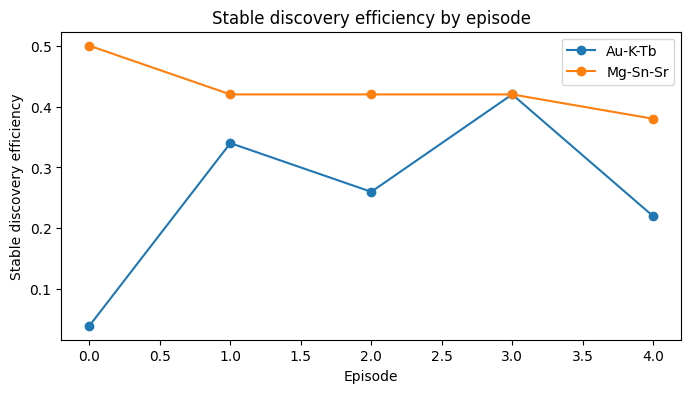

In [113]:
summary = df_episodes[['system_id', 'episode_id', 'final/num_newly_discovered_stable', 'final/stable_discovery_efficiency', 'final/convex_hull_stable_fraction']].copy()
summary = summary.rename(columns={
    'final/num_newly_discovered_stable': 'new_stable_count',
    'final/stable_discovery_efficiency': 'stable_discovery_efficiency',
    'final/convex_hull_stable_fraction': 'stable_fraction',
})
display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
for system_id, g in summary.groupby('system_id'):
    gg = g.sort_values('episode_id')
    ax.plot(gg['episode_id'], gg['stable_discovery_efficiency'], marker='o', label=system_id)
ax.set_title('Stable discovery efficiency by episode')
ax.set_xlabel('Episode')
ax.set_ylabel('Stable discovery efficiency')
ax.legend()
plt.show()


## 5) Quick Readout

Use the printed tables/plots to answer your study questions:
- **Learning from mistakes**: inspect `delta_next_*` tables and family reallocation signs (`poor` families should trend down).
- **When new families are introduced**: inspect `new_family_event` comparison and cumulative curves.
- **Family / n-ary focus shifts**: use the arity and element share plots plus top-family table.
